In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.integrate import odeint
import pandas as pd
import matplotlib.ticker as ticker

In [18]:
p = {
    'kk_1':  0.5,   
    'kk_2':  0.5,   
    'C50': 1.0,    
    'C_total': 2.0,
    'alpha_1': 0,
    'alpha_2': 0,
    'K':     1.0,    
    'beta':  0.2,    
    'mu':    0.1,    
    'rH':    0.1,   
    'rhor':  0.05,   
    'm':    3.2e-5  
}

In [19]:
y0 = [0.95,     
      0.05,   
      0.0,
      0.0,
      0.0]   
t = np.linspace(0, 2000, 2000)

In [20]:
def Hills_function (C, kk, C50):
    if C <= 0:
        return 0.0
    return (kk * C/ (C + C50))

def dose_distribution(C_total, r_2):
    C_dose1 = C_total * (1 - r_2)
    C_dose2  = C_total * r_2
    return C_dose1, C_dose2 
    
C_dose1, C_dose2 = dose_distribution(p['C_total'], 0.5)

e_1 = Hills_function(C_dose1,p['kk_1'],p['C50'])
e_2 = Hills_function(C_dose2,p['kk_2'],p['C50'])

b_ab = p['beta']*(1-e_1)*(1-e_2)
b_Ab = p['beta']*(1-p['rhor'])*(1-e_2)
b_aB = p['beta']*(1-e_1)*(1-p['rhor'])
b_AB = p['beta']*(1-p['rhor'])*(1-p['rhor'])

In [21]:
def ODEs (y,t,p,b_ab, b_Ab, b_aB, b_AB):
    H, I_ab, I_Ab, I_aB, I_AB = y
    m = p['m']
    rH = p ['rH']
    K = p['K']
    mu = p['mu']

    dH = rH*(K - H - I_ab - I_Ab - I_aB - I_AB) - b_ab*I_ab*H - b_Ab*I_Ab*H - b_aB*I_aB*H - b_AB*I_AB*H
    dI_ab = (1-2*m)*b_ab*I_ab*H + m*b_Ab*I_Ab*H + m*b_aB*I_aB*H - mu*I_ab
    dI_Ab = m*b_ab*I_ab*H + (1-2*m)*b_Ab*I_Ab*H + m*b_AB*I_AB*H - mu*I_Ab
    dI_aB = m*b_ab*I_ab*H + (1-2*m)*b_aB*I_aB*H + m*b_AB*I_AB*H - mu*I_aB
    dI_AB = m*b_Ab*I_Ab*H + m*b_aB*I_aB*H + (1-2*m)*b_AB*I_AB*H - mu*I_AB

    return [dH, dI_ab, dI_Ab, dI_aB, dI_AB]

In [22]:
def calculate_90_threshold (sol, t):
    I_total = sol[:,1] + sol[:,2] + sol[:,3] + sol[:,4]
    
    proportion_I_AB = np.divide(
        sol[:,4],
        I_total,
        out=np.zeros_like(I_total), 
        where = (I_total)!=0
    )
    
    indices = np.where(proportion_I_AB >= 0.9)[0]
    
    if len(indices) > 0:
        return t[indices[0]]
    else:
        return np.nan

In [23]:
def calculate_R0 (b_ab, b_Ab, b_aB, b_AB, p):
    R0_ab = b_ab * p['K'] / p['mu']
    R0_Ab = b_Ab * p['K'] / p['mu']
    R0_aB = b_aB * p['K'] / p['mu']
    R0_AB = b_AB * p['K'] / p['mu']
    
    return R0_ab, R0_Ab, R0_aB, R0_AB

transmission_range = np.linspace(0.01, 0.2, 9)
R0_results = []
t90_results = []
full_dynamics_transmission = []

for transmission in transmission_range:
    p_c = p.copy()
    p_c['beta'] = transmission
    
    C_dose1, C_dose2 = dose_distribution(p_c['C_total'], 0.5)

    e_1 = Hills_function(C_dose1, p_c['kk_1'], p_c['C50'])
    e_2 = Hills_function(C_dose2, p_c['kk_2'], p_c['C50'])

    b_ab = p_c['beta'] * (1 - e_1) * (1 - e_2)
    b_Ab = p_c['beta'] * (1 - p_c['rhor']) * (1 - e_2)
    b_aB = p_c['beta'] * (1 - e_1) * (1 - p_c['rhor'])
    b_AB = p_c['beta'] * (1 - p_c['rhor'])**2

    b_total = (b_ab, b_Ab, b_aB, b_AB)
  
    sol = odeint(ODEs, y0, t, args=(p_c, *b_total),)
    
    R0_ab, R0_Ab, R0_aB, R0_AB = calculate_R0(b_ab, b_Ab, b_aB, b_AB, p_c)
   
    R0_results.append([R0_ab, R0_Ab, R0_aB, R0_AB])
    t_90 = calculate_90_threshold(sol, t)
    t90_results.append(t_90)
    full_dynamics_transmission.append(sol)

In [24]:
rows = []

for i, sol in enumerate(full_dynamics_transmission):
    rows.append([
        transmission_range[i],
        sol[-1, 0],   
        sol[-1, 1],   
        sol[-1, 2],   
        sol[-1, 3],   
        sol[-1, 4],  
        R0_results[i][0],  
        R0_results[i][1],  
        R0_results[i][2],  
        R0_results[i][3],
        t90_results[i],
    ])

df_summary = pd.DataFrame(rows, columns=[
    "Transmission rate",
    "H",
    "$I_{ab}$",
    "$I_{Ab}$",
    "$I_{aB}$",
    "$I_{AB}$",
    "$R_{0,ab}$",
    "$R_{0,Ab}$",
    "$R_{0,aB}$",
    "$R_{0,AB}$",
    "90%$I_{AB}$time"
])

df_summary

,Transmission rate,H,$I_{ab}$,$I_{Ab}$,$I_{aB}$,$I_{AB}$,"$R_{0,ab}$","$R_{0,Ab}$","$R_{0,aB}$","$R_{0,AB}$",90%$I_{AB}$time
0,0.01000,1.000000,-1.145338e-15,-5.265048e-20,-5.265048e-20,-3.136156e-24,0.056250,0.071250,0.071250,0.090250,NaN
1,0.03375,1.000000,-1.303046e-14,-4.555425e-18,-4.555428e-18,-2.425263e-21,0.189844,0.240469,0.240469,0.304594,NaN
2,0.05750,1.000000,-2.521762e-14,-4.164477e-17,-4.164477e-17,-1.424392e-19,0.323438,0.409687,0.409687,0.518937,NaN
3,0.08125,1.000000,-2.571353e-14,-3.574316e-16,-3.574316e-16,-1.768780e-17,0.457031,0.578906,0.578906,0.733281,NaN
4,0.10500,1.000000,-3.496384e-13,-1.174312e-13,-1.174312e-13,1.159542e-12,0.590625,0.748125,0.748125,0.947625,481.240620
5,0.12875,0.860663,1.419999e-09,1.058704e-05,1.058704e-05,6.964710e-02,0.724219,0.917344,0.917344,1.161969,505.252626
6,0.15250,0.726626,2.786002e-09,2.077146e-05,2.077146e-05,1.366456e-01,0.857813,1.086563,1.086563,1.376313,430.215108
7,0.17625,0.628712,3.785626e-09,2.821149e-05,2.821149e-05,1.855878e-01,0.991406,1.255781,1.255781,1.590656,391.195598
8,0.20000,0.554052,4.544718e-09,3.388391e-05,3.388391e-05,2.229062e-01,1.125000,1.425000,1.425000,1.805000,388.194097


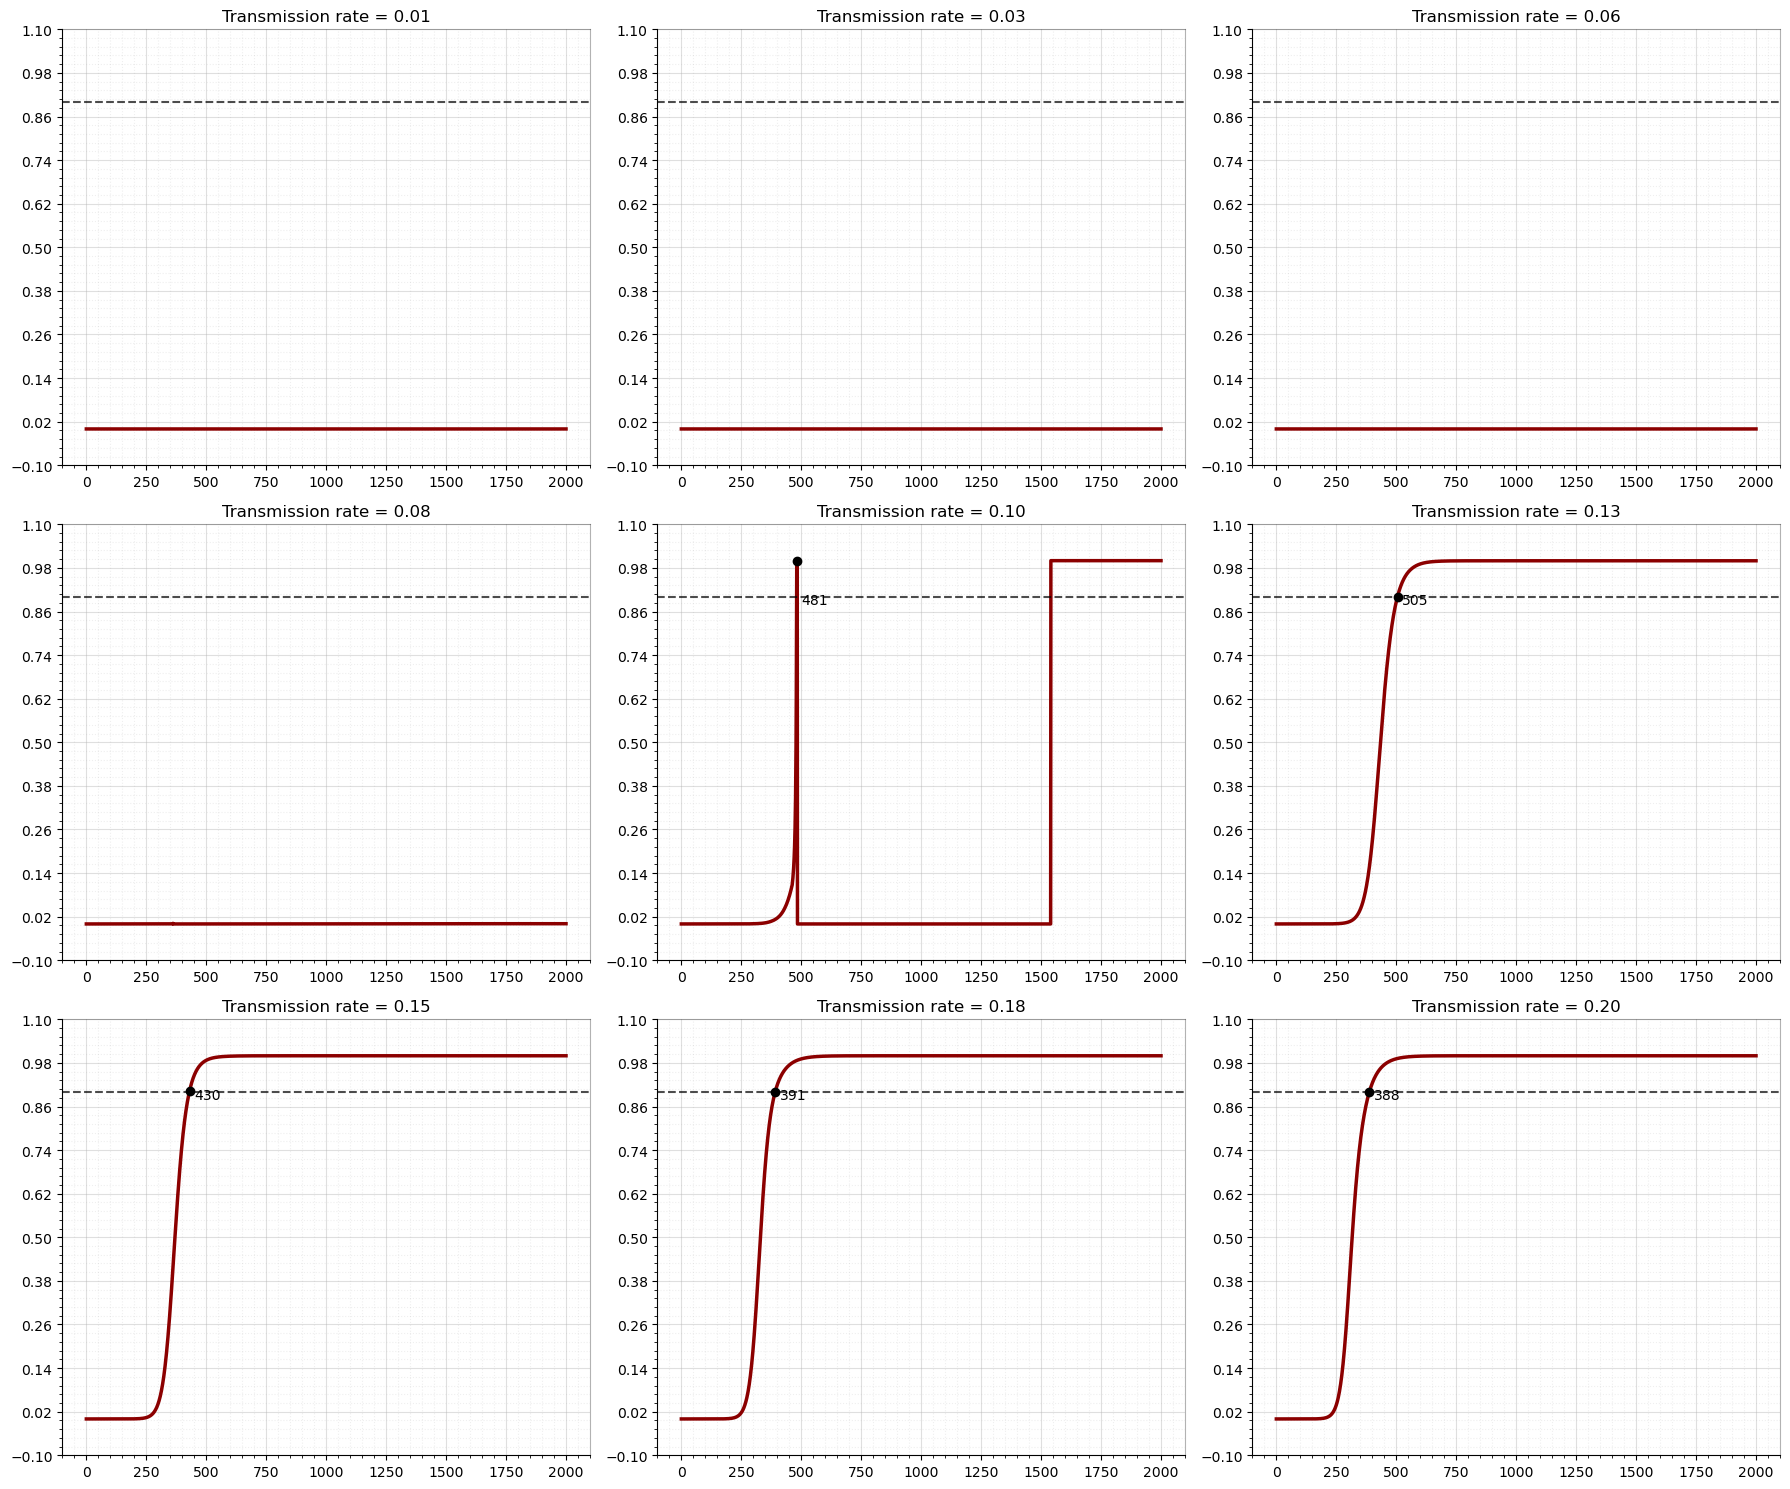

In [25]:
n = len(transmission_range)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, 5*rows), dpi=100)
axes = np.array(axes).reshape(rows, cols)

def calculate_I_AB_proportion(sol):
    I_total = sol[:,1] + sol[:,2] + sol[:,3] + sol[:,4]
    I_AB = sol[:,4]
    proportion = np.divide(I_AB, I_total, out=np.zeros_like(I_total),)
    return np.clip(proportion, 0, 1)

for i, transmission in enumerate(transmission_range):
    r = i // cols
    c = i % cols
    ax = axes[r, c]
    sol = full_dynamics_transmission[i]

    I_AB_prop = calculate_I_AB_proportion(sol)

    ax.plot(t, I_AB_prop, color='darkred', linewidth=2.5)
    ax.axhline(0.9, color='black', linestyle='--', alpha=0.7)

    indices = np.where(I_AB_prop >= 0.9)[0]
    if len(indices) > 0:
        hit_time = t[indices[0]]
        ax.plot(hit_time, I_AB_prop[indices[0]], 'ko')
        ax.text(hit_time + 20, 0.88, f'{hit_time:.0f}', fontsize=10)

    ax.set_title(f"Transmission rate = {transmission:.2f}", fontsize=12)
    ax.set_yticks(np.linspace(-0.1,1.1,11))
        
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))
        
    ax.grid(True, which='major', alpha=0.4)
    ax.grid(True, which='minor', alpha=0.2, linestyle=':')
        
    ax.spines["top"].set_alpha(0.3)
    ax.spines["right"].set_alpha(0.3)

plt.tight_layout()
plt.show()

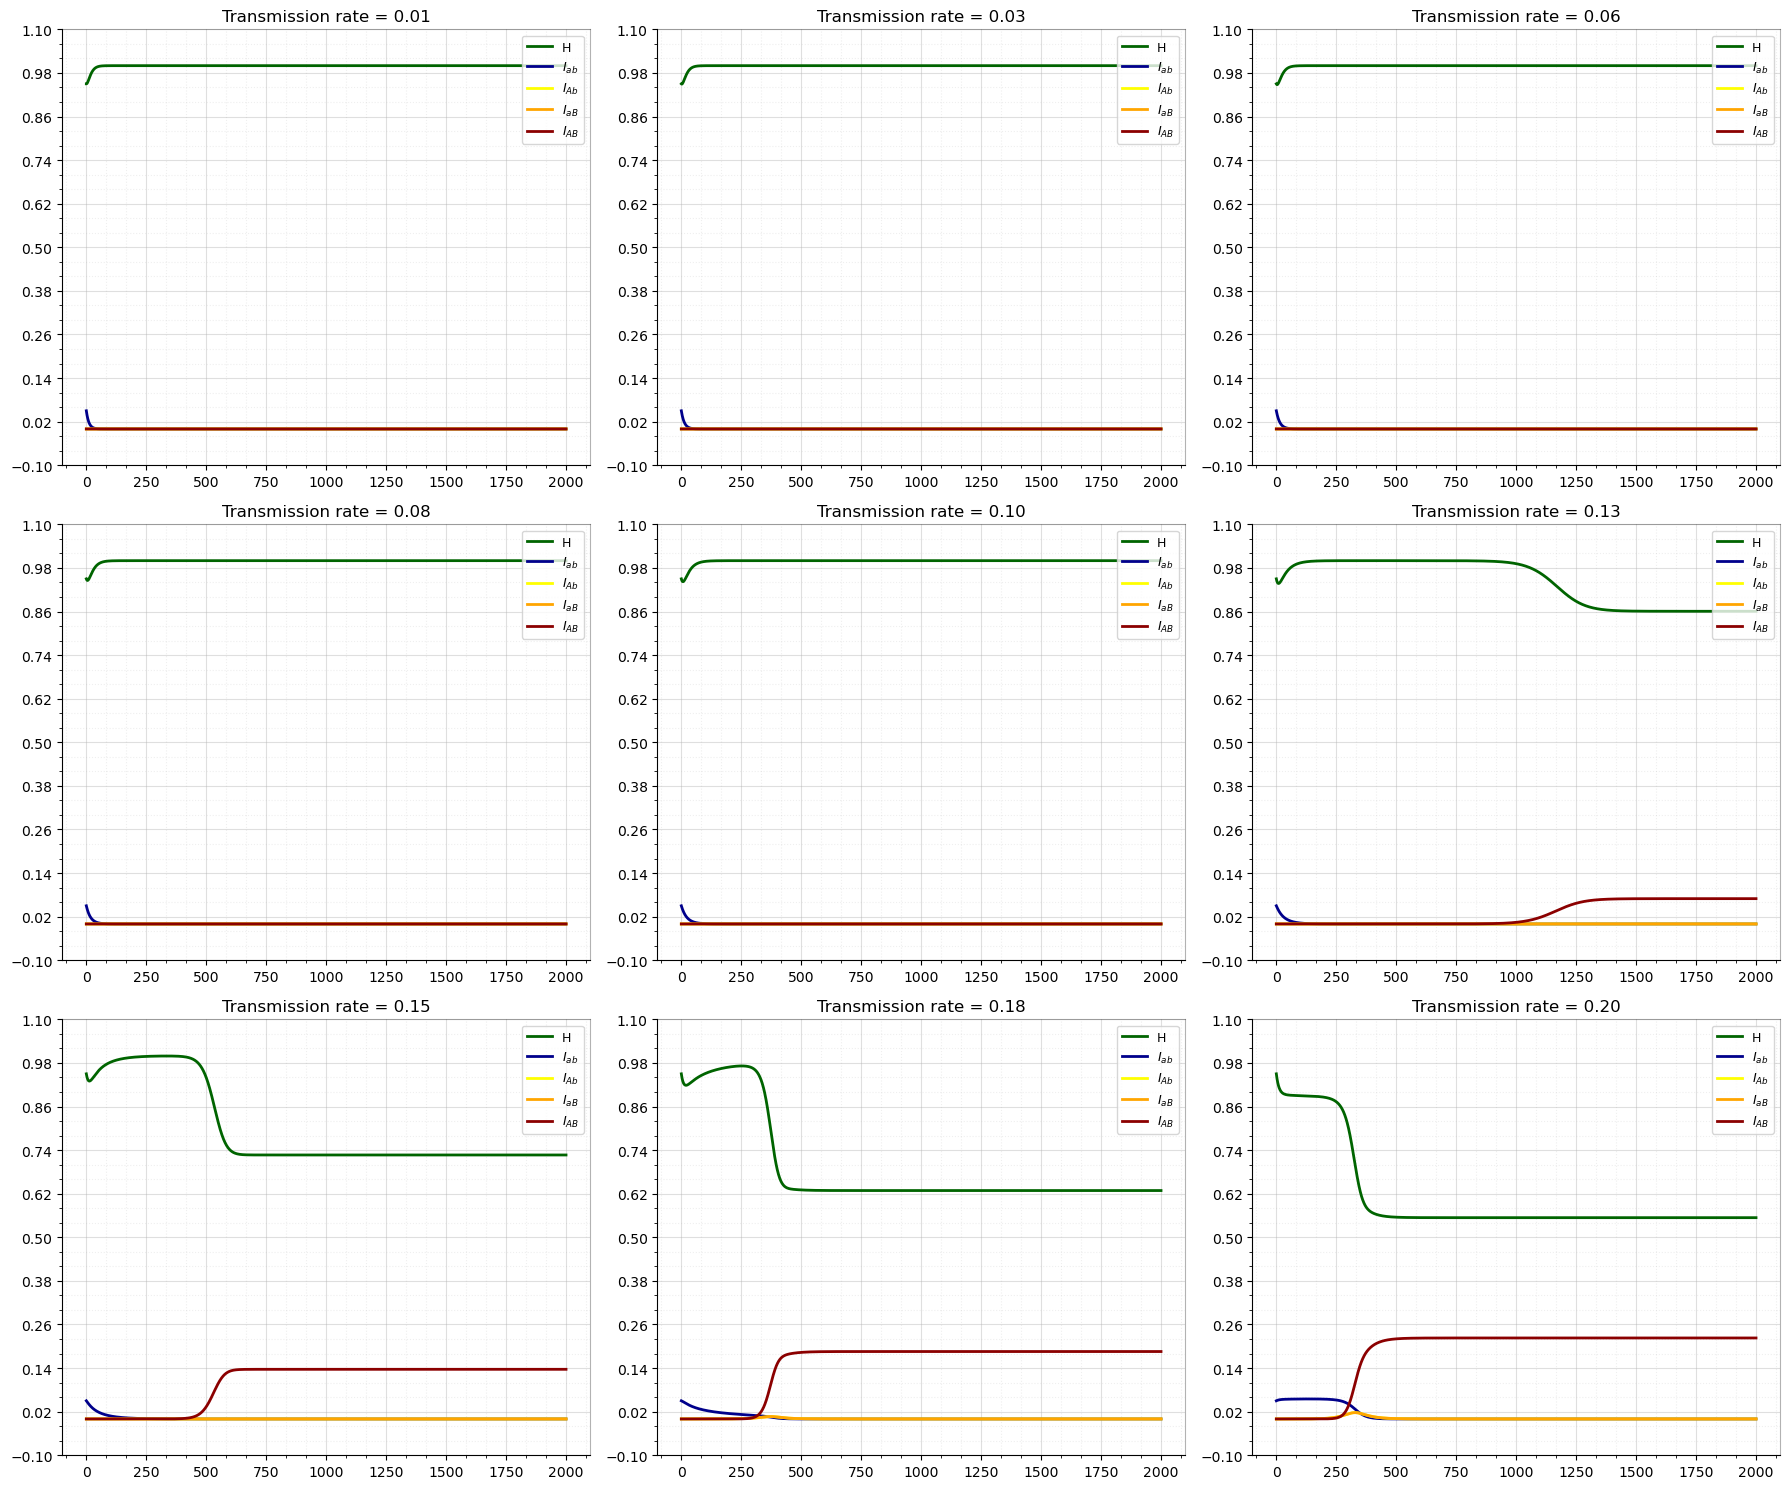

In [26]:
n = len(transmission_range)
cols = 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(18, 5*rows), dpi=100)
axes = np.array(axes).reshape(rows, cols)

labels = ['H', '$I_{ab}$', '$I_{Ab}$', '$I_{aB}$', '$I_{AB}$']
colors = ['darkgreen', 'darkblue', 'yellow', 'orange', 'darkred']

for i, transmission in enumerate(transmission_range):
    r = i // cols
    c = i % cols
    ax = axes[r, c]
    sol = full_dynamics_transmission[i]

    for j in range(5):
        ax.plot(t, sol[:, j], color=colors[j], label=labels[j], linewidth=2)

    ax.set_title(f"Transmission rate = {transmission:.2f}", fontsize=12)
    ax.set_yticks(np.linspace(-0.1, 1.1, 11))
    
    ax.legend(loc='upper right', fontsize=9)
    
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(3))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(3))
    
    ax.grid(True, which='major', alpha=0.4)
    ax.grid(True, which='minor', alpha=0.2, linestyle=':')
    
    ax.spines["top"].set_alpha(0.3)
    ax.spines["right"].set_alpha(0.3)

plt.tight_layout()
plt.show()

#### One strain model

In [97]:
p = {
    'K': 1.0,
    'rH': 0.1,
    'mu': 0.1,
    'beta': 0.2
}
y0 = [0.95, 0.05]
t = np.linspace(0, 2000, 2000)

def ODE_one_strain(y, t, p):
    H, I = y
    b = p['beta']
    dH = p['rH'] * (p['K'] - H - I) - b * I * H
    dI = b * I * H - p['mu'] * I
    return [dH, dI]

def calculate_R0(b, p):
    return b * p['K'] / p['mu']

transmission_range = np.linspace(0.01, 0.2, 9)
summary_data = []

for transmission in transmission_range:
    p_c = p.copy()
    p_c['beta'] = transmission

    sol = odeint(ODE_one_strain, y0, t, args=(p_c,))

    R0 = calculate_R0(transmission, p_c)

    summary_data.append({
        'Transmission rate':transmission,
        '$R_{0}$': R0,
        '$H^*$':sol [-1, 0],
        '$I^*$': sol[-1 ,1],  
    })

df_summary = pd.DataFrame(summary_data)
df_summary

,Transmission rate,$R_{0}$,$H^*$,$I^*$
0,0.01000,0.1000,1.000000,-4.502924e-15
1,0.03375,0.3375,1.000000,-2.073509e-14
2,0.05750,0.5750,1.000000,-1.655394e-13
3,0.08125,0.8125,1.000000,-1.372966e-11
4,0.10500,1.0500,0.952380,2.380997e-02
5,0.12875,1.2875,0.776699,1.116505e-01
6,0.15250,1.5250,0.655738,1.721311e-01
7,0.17625,1.7625,0.567376,2.163121e-01
8,0.20000,2.0000,0.500000,2.500000e-01
